In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates.

# Depth Estimation <a target="_blank" href="https://colab.research.google.com/github/facebookresearch/dinov2/blob/main/notebooks/depth_estimation.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import sys

LOCAL_PATH = "/home/ezalos/42/art/comfyui/swag_mirror/dinov2"
if LOCAL_PATH not in sys.path:
    sys.path.insert(0, LOCAL_PATH)
    print(f"{sys.path = }")

LOCAL_PATH = "/home/ezalos/42/Notebooks2Teach/PreciousZoo"
if LOCAL_PATH not in sys.path:
    sys.path.insert(0, LOCAL_PATH)
    print(f"{sys.path = }")

from utils.gpu_memory import measure_model_memory_impact, log_gpu_memory

sys.path = ['/home/ezalos/42/art/comfyui/swag_mirror/dinov2', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages']
sys.path = ['/home/ezalos/42/Notebooks2Teach/PreciousZoo', '/home/ezalos/42/art/comfyui/swag_mirror/dinov2', '/usr/lib/python310.zip', '/usr/lib/python3.10', '/usr/lib/python3.10/lib-dynload', '', '/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages']


## Utilities

## Load pretrained backbone

In [3]:
import torch


@measure_model_memory_impact
def load_backbone(backbone_size):
    # BACKBONE_SIZE = "small" # in ("small", "base", "large" or "giant")

    backbone_archs = {
		"small": "vits14",
		"base": "vitb14",
		"large": "vitl14",
		"giant": "vitg14",
	}
    backbone_arch = backbone_archs[backbone_size]
    backbone_name = f"dinov2_{backbone_arch}"

    backbone_model = torch.hub.load(
        repo_or_dir="facebookresearch/dinov2", model=backbone_name
    )
    backbone_model.eval()
    backbone_model.cuda()
    backbone_name = f"dinov2_{backbone_arch}"
    return backbone_model, backbone_name

## Load pretrained depth head

## Load sample image

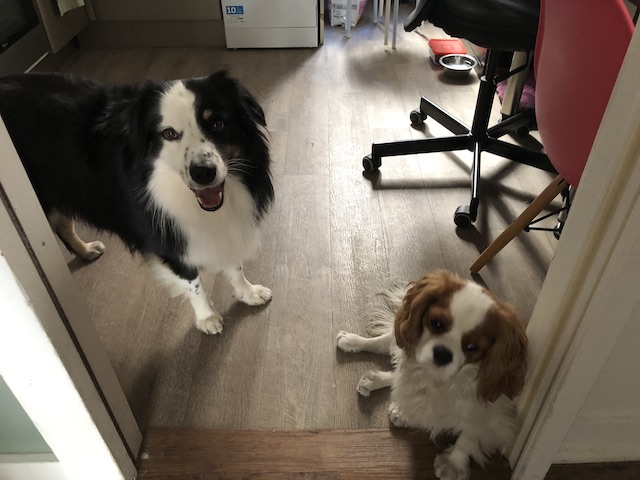

In [4]:
import urllib

from PIL import Image


def load_image_from_url(url: str) -> Image:
    with urllib.request.urlopen(url) as f:
        return Image.open(f).convert("RGB")


EXAMPLE_IMAGE_URL = "https://dl.fbaipublicfiles.com/dinov2/images/example.jpg"


image = load_image_from_url(EXAMPLE_IMAGE_URL)
display(image)

## Estimate depth on sample image

In [5]:
import matplotlib
from torchvision import transforms


def make_depth_transform() -> transforms.Compose:
    return transforms.Compose([
        transforms.ToTensor(),
        lambda x: 255.0 * x[:3], # Discard alpha component and scale by 255
        transforms.Normalize(
            mean=(123.675, 116.28, 103.53),
            std=(58.395, 57.12, 57.375),
        ),
    ])


log_gpu_memory("Before depth image")
transform = make_depth_transform()

scale_factor = 1
rescaled_image = image.resize((scale_factor * image.width, scale_factor * image.height))

# Resize image to be multiple of patch size (14x14)
target_height = (rescaled_image.height // 14) * 14
target_width = (rescaled_image.width // 14) * 14
rescaled_image = rescaled_image.resize((target_width, target_height))


transformed_image = transform(rescaled_image)
print(f"{transformed_image.shape = } {transformed_image.dtype = }")



GPU Memory Usage Before depth image: [GPU-LEAK ?] Allocated: 0.00GB (Peak: 0.00GB) | Reserved: 0.00GB (Peak: 0.00GB)
transformed_image.shape = torch.Size([3, 476, 630]) transformed_image.dtype = torch.float32


In [6]:
def warmup_model(model, transformed_image):
    batch = transformed_image.unsqueeze(0).cuda()  # Make a batch of one image

    with torch.inference_mode():
        result = model.forward(batch)
        result = model.forward(batch)
        result = model.forward(batch)
    return result

In [7]:
def benchmark_batch_size(model, transformed_image, N):
    start = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)

    log_gpu_memory(f"Before batch processing of {N=}")
    # Create batch of N=8 copies of the same image
    batch = transformed_image.repeat(N, 1, 1, 1).cuda()
    print(f"{batch.shape = } {batch.dtype = }")

    with torch.inference_mode():
        start.record()
        result = model.forward(batch)
        end.record()

    torch.cuda.synchronize()
    print(f"{result.shape = } {result.dtype = }")
    elapsed_time = start.elapsed_time(end)
    print(f"Elapsed time: {elapsed_time:.2f} ms")

    memstats = log_gpu_memory(f"After batch processing of {N=}")

    return elapsed_time, memstats.peak_allocated

In [8]:
import pandas as pd

SIZE_TO_BENCHMARK = [1, 2, 4, 8, 16, 32, 64, 128, 256, 512]
BACKBONE_SIZE = "small"
SIZE_TO_BENCHMARK = [1, 2, 4, 8, 16, 32, 64, 128, 256]
BACKBONE_SIZE = "base"
SIZE_TO_BENCHMARK = [1, 2, 4, 8, 16, 32, 64, 128]
BACKBONE_SIZE = "large"
SIZE_TO_BENCHMARK = [1, 2, 4, 8, 16, 32, 64]
BACKBONE_SIZE = "giant"
backbone_model, backbone_name = load_backbone(BACKBONE_SIZE)

model = backbone_model
model.eval()
model.cuda()

warmup_model(model, transformed_image)

df = pd.DataFrame(columns=["N", "Time (ms)", "Memory (GB)", "BACKBONE_SIZE"])

for N in SIZE_TO_BENCHMARK:
    elapsed_time, peak_memory = benchmark_batch_size(model, transformed_image, N)
    df.loc[len(df)] = [N, elapsed_time, peak_memory, BACKBONE_SIZE]

# Save results to CSV
csv_filename = f"DINOv2_{BACKBONE_SIZE}_time_vs_vRAM.csv"
df.to_csv(csv_filename, index=False)
print(f"Results saved to {csv_filename}")

GPU Memory before load_backbone: [GPU-LEAK ?] Allocated: 0.00GB (Peak: 0.00GB) | Reserved: 0.00GB (Peak: 0.00GB)


Using cache found in /home/ezalos/.cache/torch/hub/facebookresearch_dinov2_main
/home/ezalos/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/ezalos/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:27: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/ezalos/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitg14/dinov2_vitg14_pretrain.pth" to /home/ezalos/.cache/torch/hub/checkpoints/dinov2_vitg14_pretrain.pth
100%|██████████| 4.23G/4.23G [00:40<00:00, 112MB/s] 


GPU Memory impact of load_backbone: [GPU-LEAK ?] Allocated: 4.27GB (Peak: 4.27GB) | Reserved: 4.32GB (Peak: 4.32GB)


/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages/xformers/ops/unbind.py:46: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage_data_ptr = tensors[0].storage().data_ptr()
/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages/xformers/ops/unbind.py:48: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if x.storage().data_ptr() != storage_data_ptr:


GPU Memory Usage Before batch processing of N=1: [GPU-LEAK ?] Allocated: 4.28GB (Peak: 4.41GB) | Reserved: 4.48GB (Peak: 4.48GB)
batch.shape = torch.Size([1, 3, 476, 630]) batch.dtype = torch.float32


...

result.shape = torch.Size([16, 1536]) result.dtype = torch.float32
Elapsed time: 2941.21 ms
GPU Memory Usage After batch processing of N=16: [GPU-LEAK ?] Allocated: 4.47GB (Peak: 6.25GB) | Reserved: 7.38GB (Peak: 7.38GB)
GPU Memory Usage Before batch processing of N=32: [GPU-LEAK ?] Allocated: 4.28GB (Peak: 6.25GB) | Reserved: 7.38GB (Peak: 7.38GB)
batch.shape = torch.Size([32, 3, 476, 630]) batch.dtype = torch.float32


/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages/xformers/ops/unbind.py:46: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage_data_ptr = tensors[0].storage().data_ptr()
/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages/xformers/ops/unbind.py:48: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if x.storage().data_ptr() != storage_data_ptr:


result.shape = torch.Size([32, 1536]) result.dtype = torch.float32
Elapsed time: 6900.83 ms
GPU Memory Usage After batch processing of N=32: [GPU-LEAK ?] Allocated: 4.67GB (Peak: 8.22GB) | Reserved: 10.46GB (Peak: 10.46GB)
GPU Memory Usage Before batch processing of N=64: [GPU-LEAK ?] Allocated: 4.28GB (Peak: 8.22GB) | Reserved: 10.46GB (Peak: 10.46GB)
batch.shape = torch.Size([64, 3, 476, 630]) batch.dtype = torch.float32


/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages/xformers/ops/unbind.py:46: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  storage_data_ptr = tensors[0].storage().data_ptr()
/home/ezalos/42/art/comfyui/venv/lib/python3.10/site-packages/xformers/ops/unbind.py:48: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  if x.storage().data_ptr() != storage_data_ptr:


result.shape = torch.Size([64, 1536]) result.dtype = torch.float32
Elapsed time: 14171.64 ms
GPU Memory Usage After batch processing of N=64: [GPU-LEAK ?] Allocated: 5.06GB (Peak: 12.16GB) | Reserved: 16.64GB (Peak: 16.64GB)
Results saved to DINOv2_giant_time_vs_vRAM.csv


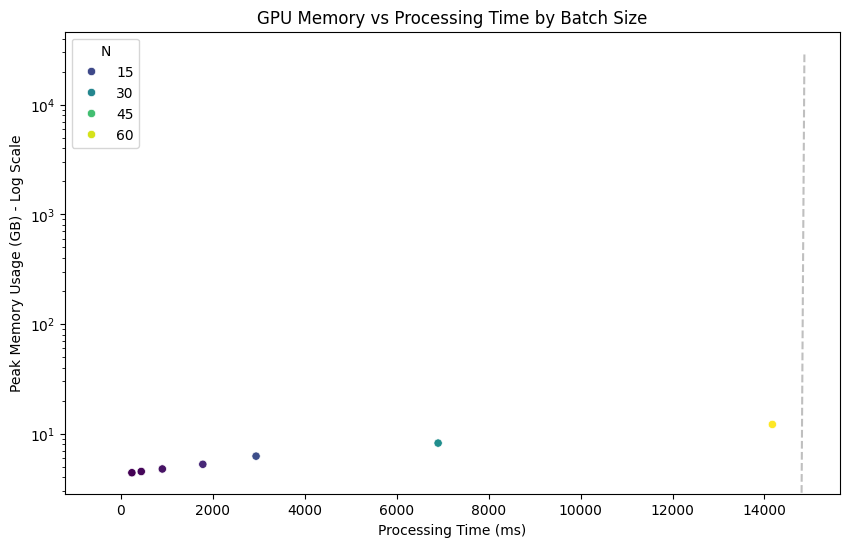

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="Time (ms)",
    y="Memory (GB)",
    hue="BACKBONE_SIZE",
    # size="N",
    # sizes=(20, 200),
    palette="viridis",
)

# Set y-axis to log scale
plt.yscale('log')

# Add reference line y = 2x
x_range = plt.xlim()
plt.plot(x_range, [2*x for x in x_range], color='grey', alpha=0.5, linestyle='--')

plt.title("GPU Memory vs Processing Time by Batch Size")
plt.xlabel("Processing Time (ms)")
plt.ylabel("Peak Memory Usage (GB) - Log Scale")
plt.show()

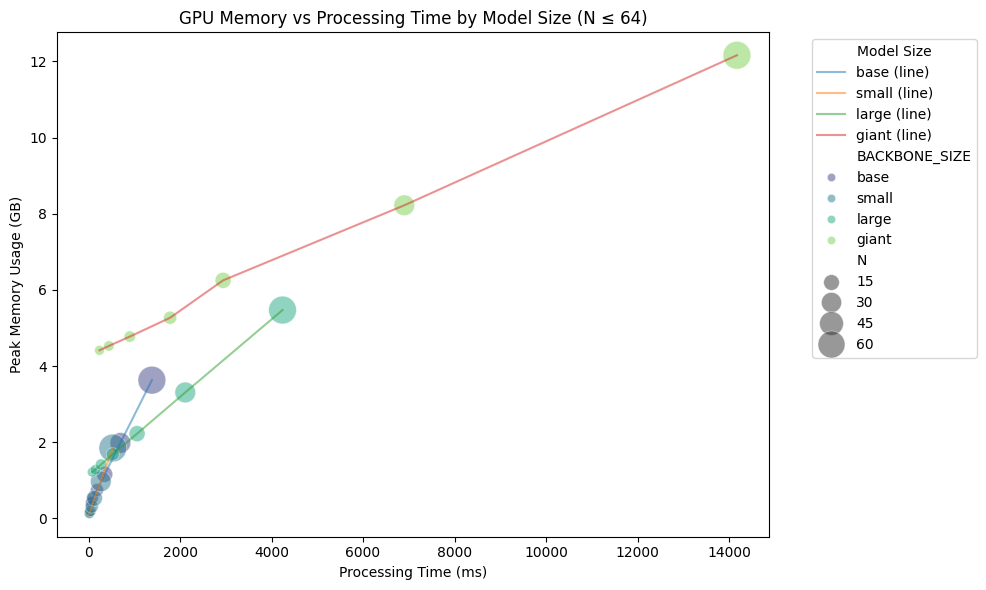

In [11]:
# Read the combined results
df_all = pd.read_csv("DINOv2_time_vs_vRAM.csv")

# Filter for N <= 64
df_filtered = df_all[df_all["N"].isin([1, 2, 4, 8, 16, 32, 64])]

# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot lines for each backbone size
for backbone in df_filtered['BACKBONE_SIZE'].unique():
    df_backbone = df_filtered[df_filtered['BACKBONE_SIZE'] == backbone]
    plt.plot(df_backbone['Time (ms)'], df_backbone['Memory (GB)'], 
             alpha=0.5, label=f'{backbone} (line)')

# Add scatter points
sns.scatterplot(
    data=df_filtered,
    x="Time (ms)", 
    y="Memory (GB)",
    hue="BACKBONE_SIZE",
    size="N",
    sizes=(50, 400),
    palette="viridis",
    alpha=0.5
)

plt.title("GPU Memory vs Processing Time by Model Size (N ≤ 64)")
plt.xlabel("Processing Time (ms)")
plt.ylabel("Peak Memory Usage (GB)")

# Add legend
plt.legend(title="Model Size", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()



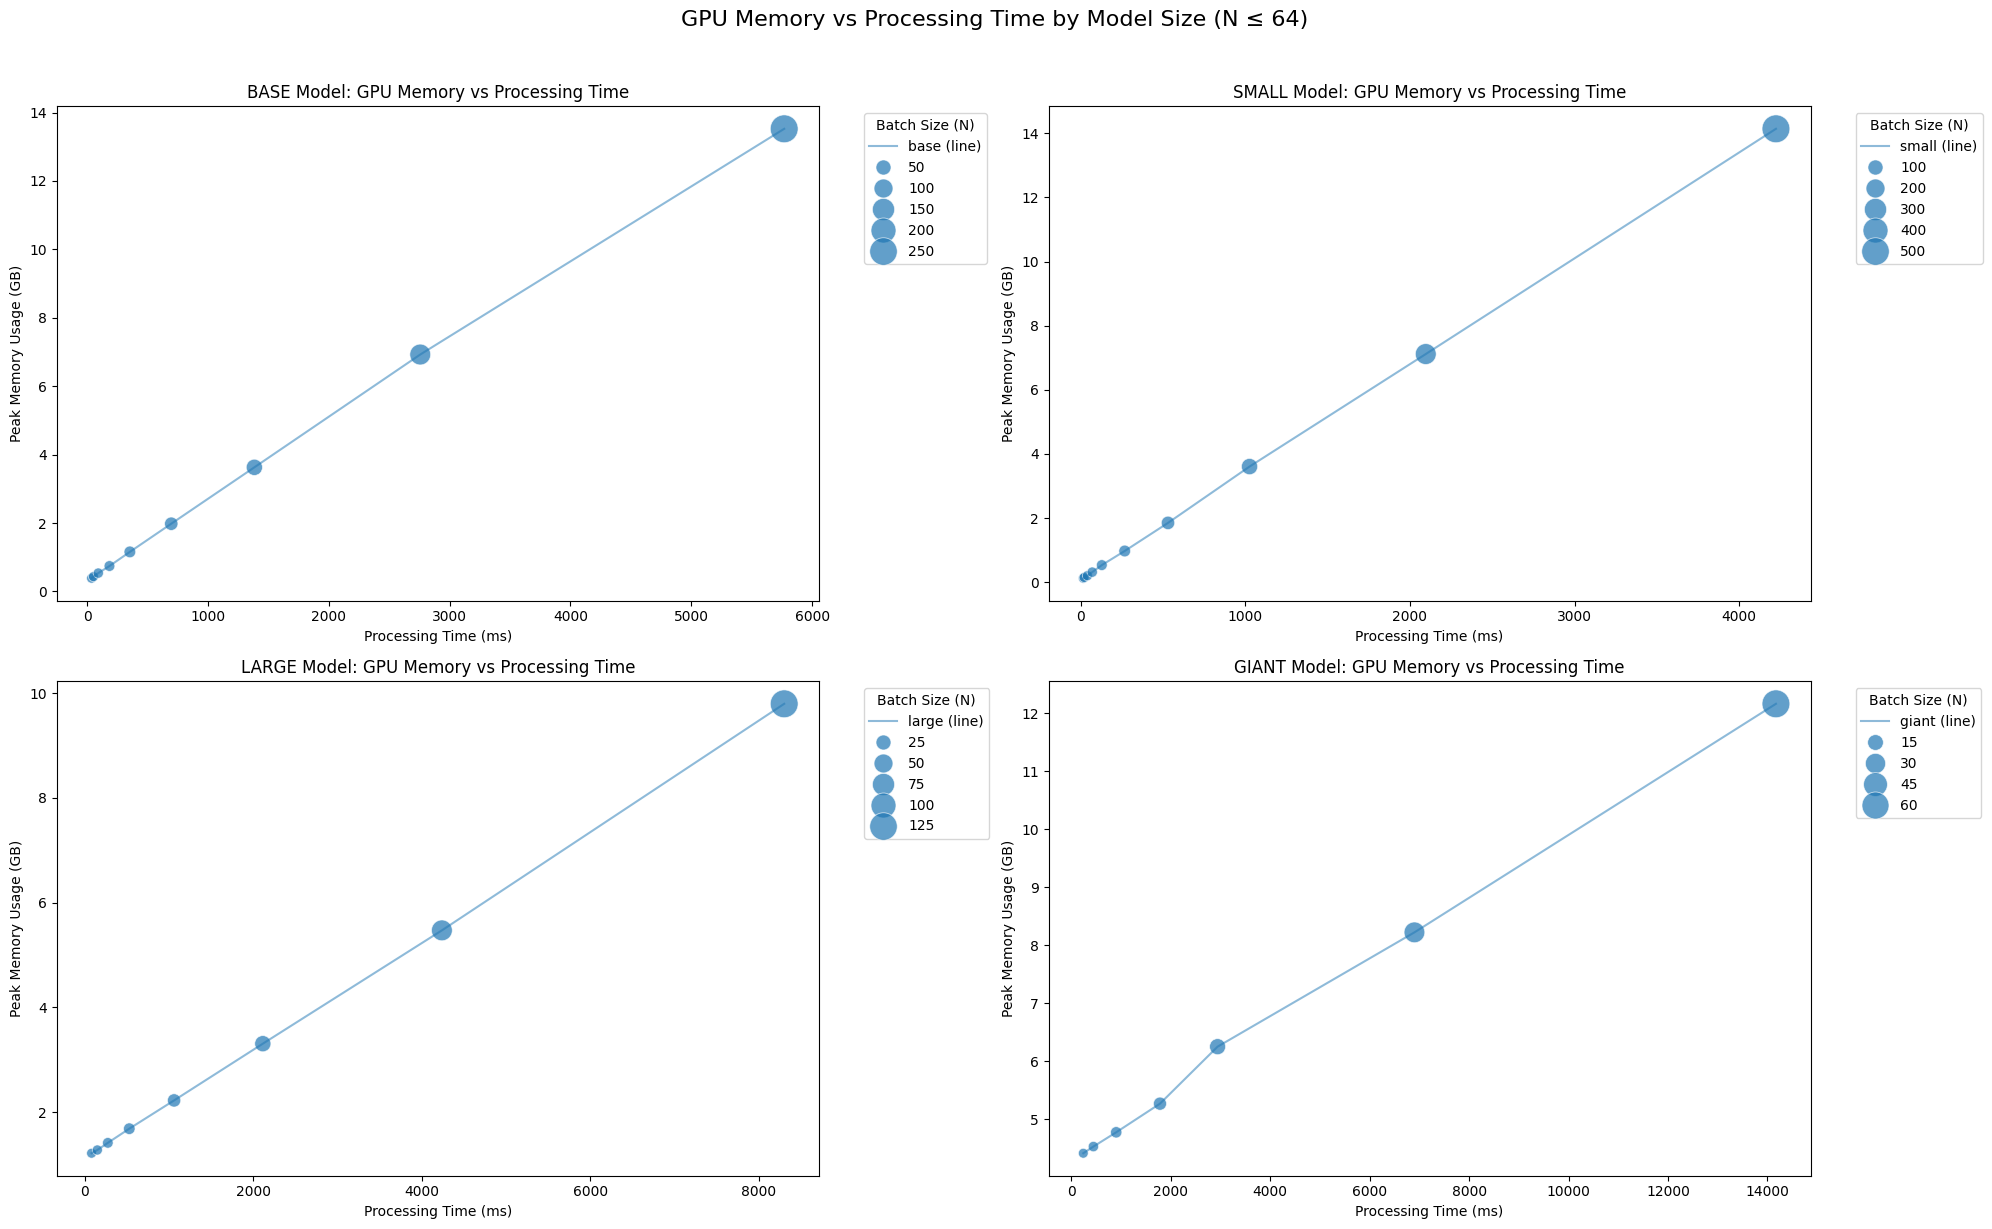

In [13]:
# Read the combined results
df_all = pd.read_csv("DINOv2_time_vs_vRAM.csv")

# Filter for N <= 64
# df_filtered = df_all[df_all["N"].isin([1, 2, 4, 8, 16, 32, 64])]
df_filtered = df_all

# Create subplots for each backbone size
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

# Plot each backbone size separately
for idx, backbone in enumerate(df_filtered["BACKBONE_SIZE"].unique()):
    df_backbone = df_filtered[df_filtered["BACKBONE_SIZE"] == backbone]
    
    # Plot line
    axes[idx].plot(
        df_backbone["Time (ms)"],
        df_backbone["Memory (GB)"],
        alpha=0.5,
        label=f"{backbone} (line)",
    )

    # Add scatter points
    sns.scatterplot(
        data=df_backbone,
        x="Time (ms)",
        y="Memory (GB)",
        size="N",
        sizes=(50, 400),
        ax=axes[idx],
        alpha=0.7
    )

    axes[idx].set_title(f"{backbone.upper()} Model: GPU Memory vs Processing Time")
    axes[idx].set_xlabel("Processing Time (ms)")
    axes[idx].set_ylabel("Peak Memory Usage (GB)")
    axes[idx].legend(title="Batch Size (N)", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.suptitle("GPU Memory vs Processing Time by Model Size (N ≤ 64)", y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

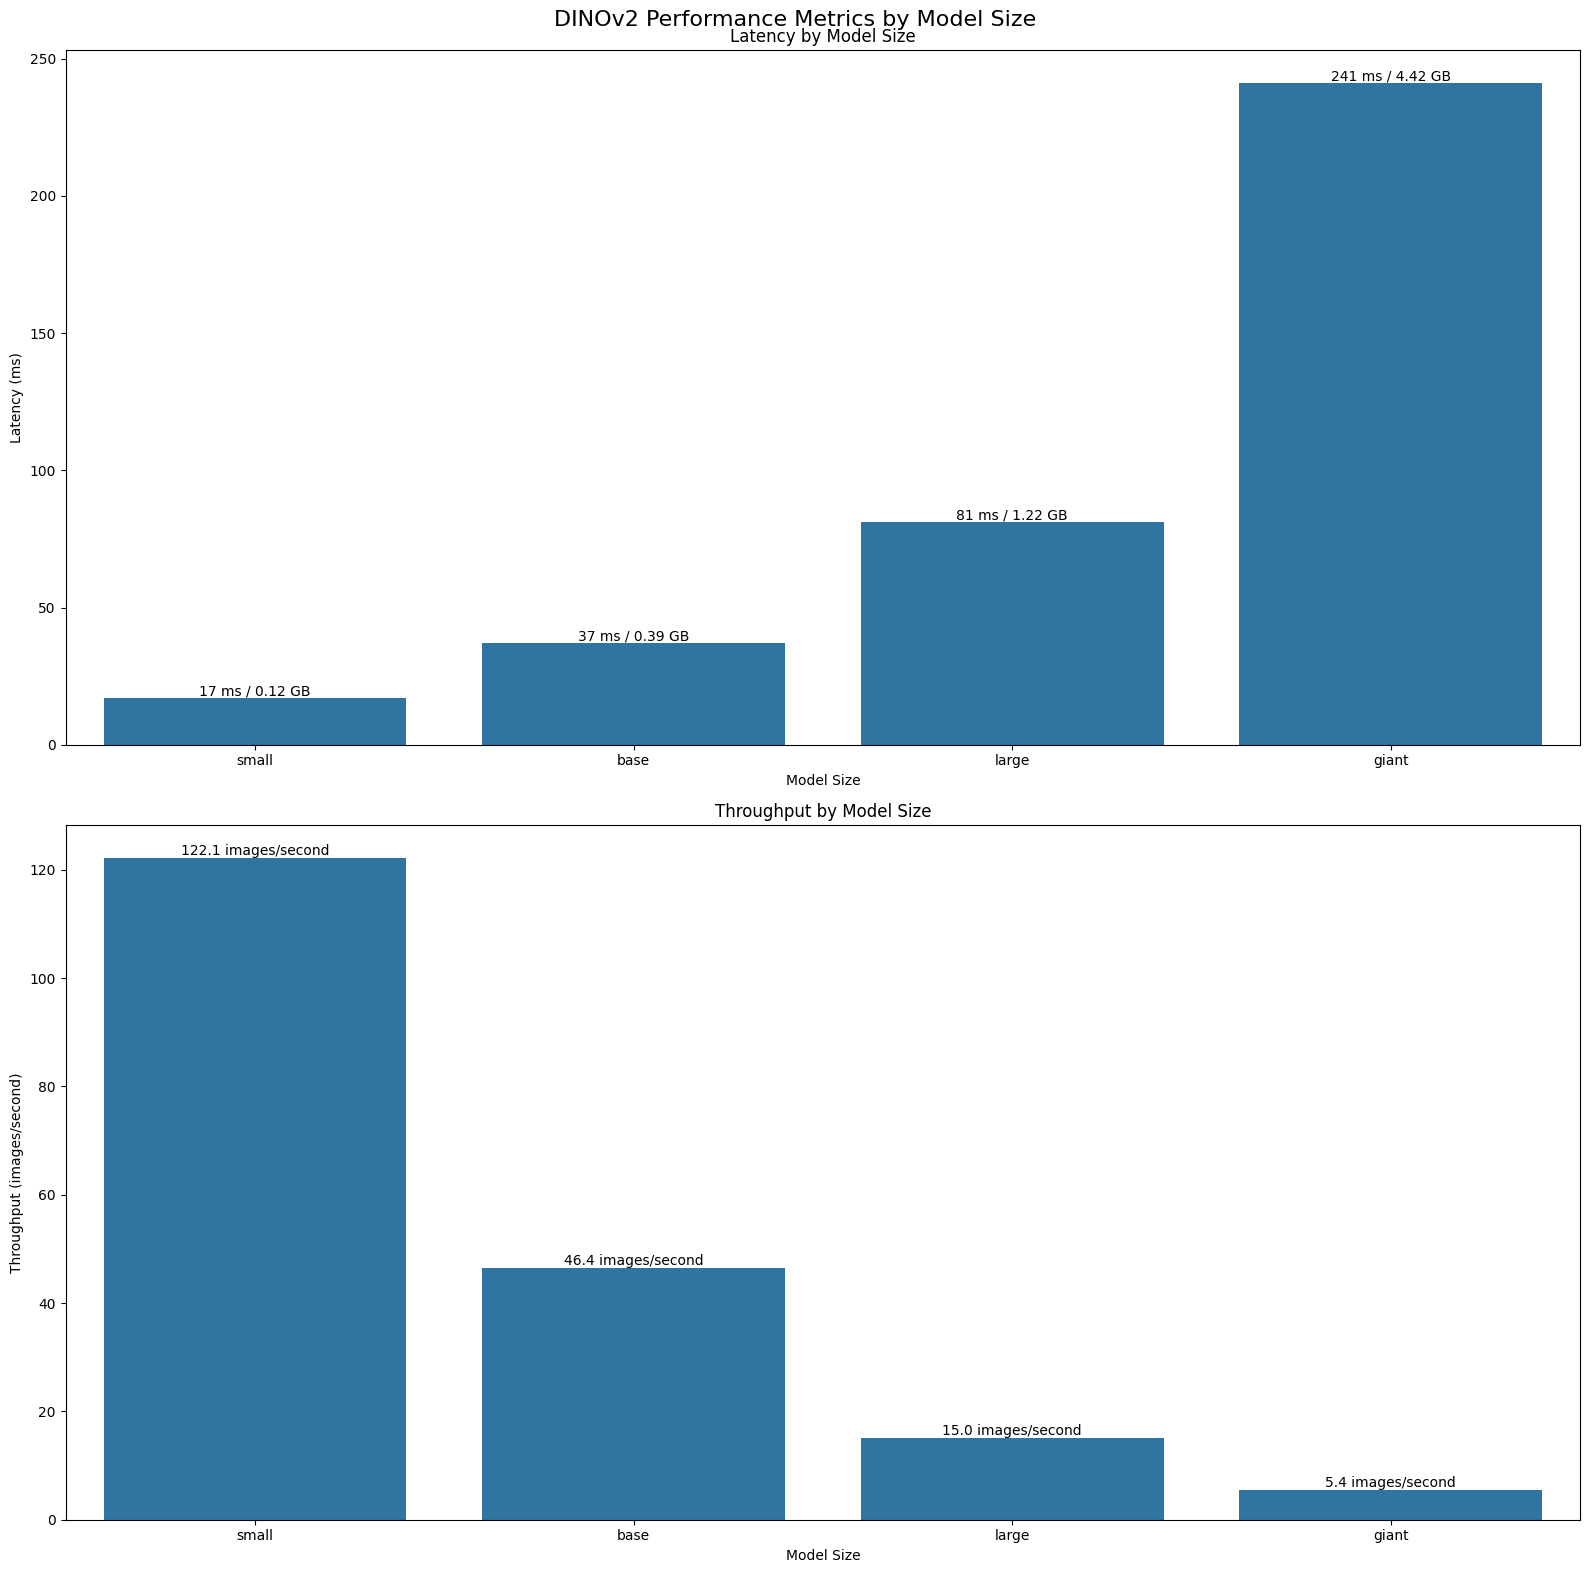

In [17]:
# Create data for latency and throughput
latency_data = {
    'Model Size': ['small', 'base', 'large', 'giant'],
    'Latency (ms)': [17, 37, 81, 241],
    'vRAM (GB)': [0.121, 0.39, 1.22, 4.42],
    'Throughput (img/s)': [122.1, 46.4, 15.0, 5.4]
}
df_metrics = pd.DataFrame(latency_data)

# Create figure with two subplots vertically
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 16))

# Plot 1: Latency
bars1 = sns.barplot(data=df_metrics, x='Model Size', y='Latency (ms)', ax=ax1)
ax1.set_title('Latency by Model Size')
ax1.set_ylabel('Latency (ms)')

# Add latency and vRAM values on top of bars for latency plot
for i, bar in enumerate(bars1.patches):
    latency = df_metrics['Latency (ms)'].iloc[i]
    vram = df_metrics['vRAM (GB)'].iloc[i]
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{latency:.0f} ms / {vram:.2f} GB',
        ha='center',
        va='bottom'
    )

# Plot 2: Throughput
bars2 = sns.barplot(data=df_metrics, x='Model Size', y='Throughput (img/s)', ax=ax2)
ax2.set_title('Throughput by Model Size')
ax2.set_ylabel('Throughput (images/second)')

# Add throughput values on top of bars
for i, bar in enumerate(bars2.patches):
    throughput = df_metrics['Throughput (img/s)'].iloc[i]
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f'{throughput:.1f} images/second',
        ha='center',
        va='bottom'
    )

plt.suptitle('DINOv2 Performance Metrics by Model Size', fontsize=16)
plt.tight_layout()
plt.show()
